In [1]:
# import standard libraries 
import random
import numpy as np
import matplotlib.pyplot as plt
#import local modules
from blochstate1d import OLConstants, GroundBlochState
from errors_momentum_space import momentum_space_population, get_error
from nelder_mead_algorithm import sort_errors, nelder_mead
from crab_propagation_tools import OpticalLatticeHamiltonian, make_controls_fn, make_total_base_pulse

from QuEvolutio.quevolutio.core.domain import QuantumHilbertSpace, TimeGrid
from QuEvolutio.quevolutio.core.aliases import (  # isort: skip
    RVector,
    GVector,
    RVectorSeq,
    CTensors,
    CSRMatrix,
)
from QuEvolutio.quevolutio.propagators.split_operator import SplitOperator
from typing import cast
import os

In [32]:
constants = OLConstants()
# Define max number of iterations for the optimisation
n_max = 150
# Define the target size we want our error to be
target_error = 0.001
# Define parameters of our crab decomposition
N_basis = constants.N_basis # number of basis states in our decomposition
n_c = N_basis + 1 # number of vertices in our simplex
n_w = N_basis // 2 # number of omegas, also the number of sines or cosines in our shaking function

# Generate initial amplitudes and frequencies
a = np.random.uniform(-1, 1, size=(n_w, n_c))
b = np.random.uniform(-1, 1, size=(n_w, n_c))
r = np.random.uniform(-0.5, 0.5, size=n_w)
omegas = np.zeros(n_w)
scaled_freq = 0.6274360876 # 25 kHz in simulation units
for i in range(n_w):
    omegas[i] = 2 * np.pi * (i + 1) * (1 + r[i]) * (scaled_freq / n_w)


In [3]:
# Run first iteration
errors = np.zeros(n_c)
for i in range(n_c):
    errors[i]  = get_error(a[:,i], b[:,i], omegas, N_basis, base_pulse=lambda t:0.0)
    print(f"Initial error for vertex {i+1}: {errors[i]:.6f}")

sorted_errs, sorted_a, sorted_b = sort_errors(errors, a, b)
print("Sorted Errors:", sorted_errs)
print("Sorted a Coefficients:", sorted_a)
print("Sorted b Coefficients:", sorted_b)    

Initial error for vertex 1: 49.913534
Initial error for vertex 2: 44.928751
Initial error for vertex 3: 85.640384
Initial error for vertex 4: 11.928890
Initial error for vertex 5: 81.855467
Initial error for vertex 6: 28.470765
Initial error for vertex 7: 1.706045
Initial error for vertex 8: 8.180506
Initial error for vertex 9: 76.186376
Initial error for vertex 10: 58.382223
Initial error for vertex 11: 8.778247
Sorted Errors: [ 1.70604545  8.18050599  8.77824744 11.92888963 28.47076488 44.92875122
 49.91353408 58.38222339 76.18637562 81.85546659 85.64038357]
Sorted a Coefficients: [[-0.44691865 -0.28254113  0.71970438  0.31308577  0.12260083  0.033743
  -0.64116348  0.83380449  0.77545679 -0.31060264 -0.70191303]
 [ 0.85673142 -0.07180033 -0.53333207 -0.48777308  0.21807814 -0.77937682
  -0.39989841 -0.1435679   0.51093342 -0.72752954 -0.24160646]
 [-0.580374   -0.44833685 -0.12081627 -0.22234923  0.93755186  0.24773974
   0.38449137 -0.93507154  0.79555971 -0.11485653 -0.75021246]
 

In [ ]:
# this was for running the best solution i had again to see if i could get it any better with more iterations
# dont run this if trying a new one
sorted_a = np.loadtxt(f"crab_coefficients/sorted_A_0p009865.txt")
sorted_b = np.loadtxt(f"crab_coefficients/sorted_B_0p009865.txt")
omegas =  np.loadtxt(f"crab_coefficients/omegas_0p009865.txt")
sorted_errs = np.loadtxt(f"crab_coefficients/sorted_errs_0p009865.txt")

In [34]:
# Set up arrays for tracking optimisation
best_errs = []
best_errs.append(sorted_errs[0])
all_errs = np.zeros((n_max, n_c))
all_errs[0, :] = sorted_errs

base_pulses=[]

In [35]:
# Run Nelder Mead optimisation
for i in range(1, n_max):
    print(f"Iteration {i+1}")
    base_pulse = make_total_base_pulse(base_pulses)
    sorted_errs, sorted_a, sorted_b, err_NM, N_calls = nelder_mead(sorted_errs, sorted_a, sorted_b, N_basis, omegas, n_c, n_w, base_pulse)
    all_errs[i, :] = sorted_errs
    best_errs.append(sorted_errs[0])
    print(f"Best error after iteration {i+1}: {sorted_errs[0]:.6f}")
    print(f"Worst error after iteration {i+1}: {sorted_errs[-1]:.6f}")
    print(f"Diff between best and worst error after iteration {i+1}: {(sorted_errs[-1] - sorted_errs[0]):.6f}")
    print(f"Number of new points generated in iteration{i+1}: {N_calls}")
    # Stop the loop if the error is as small as we want it 
    if sorted_errs[0] < target_error:
        break
    # Generate new basis if it has converged on a local minima (dCRAB)
    if len(best_errs) > 30 and abs(best_errs[-1] - best_errs[-30]) < 1e-6:
        print("dCRAB - Generating new basis")
        # Generate new coefficients
        a = np.random.uniform(-1, 1, size=(n_w, n_c))
        b = np.random.uniform(-1, 1, size=(n_w, n_c))
        r = np.random.uniform(-0.5, 0.5, size=n_w)
        omegas_new = np.zeros(n_w)
        for j in range(n_w):
            omegas_new[j] = 2 * np.pi * (j + 1) * (1 + r[j]) * (scaled_freq / n_w)
        # Add the best shaking function from this iteration to the base pulse
        base_pulses.append(make_controls_fn(N_basis, sorted_a[:,0], sorted_b[:,0], omegas, constants.T, lambda t: 0.0))
        # Sum the base pulses to make the new shaking function
        base_pulse = make_total_base_pulse(base_pulses)
        # Get errors for new dCRAB shaking functions
        errors = np.zeros(n_c)
        for k in range(n_c):
            errors[k]  = get_error(a[:,k], b[:,k], omegas_new, N_basis, base_pulse)
        sorted_errs, sorted_a, sorted_b = sort_errors(errors, a, b)
        omegas = omegas_new
        

Iteration 2
Best error after iteration 2: 0.008269
Worst error after iteration 2: 0.011268
Diff between best and worst error after iteration 2: 0.002999
Number of new points generated in iteration2: 2
Iteration 3
Best error after iteration 3: 0.008269
Worst error after iteration 3: 0.011179
Diff between best and worst error after iteration 3: 0.002910
Number of new points generated in iteration3: 1
Iteration 4
Best error after iteration 4: 0.008269
Worst error after iteration 4: 0.011150
Diff between best and worst error after iteration 4: 0.002881
Number of new points generated in iteration4: 2
Iteration 5
Best error after iteration 5: 0.008269
Worst error after iteration 5: 0.011060
Diff between best and worst error after iteration 5: 0.002790
Number of new points generated in iteration5: 1
Iteration 6
Best error after iteration 6: 0.008269
Worst error after iteration 6: 0.010922
Diff between best and worst error after iteration 6: 0.002653
Number of new points generated in iteration

In [36]:
# Retrieve A and B coefficients and error from the final iteration
base_pulse = make_total_base_pulse(base_pulses)
optimised_A = sorted_a[:,0]
optimised_B = sorted_b[:,0]
optimised_err = get_error(optimised_A, optimised_B, omegas, N_basis, base_pulse)
# Make a folder to store the best coefficients and save them
folder = "crab_coefficients"
os.makedirs(folder, exist_ok=True)
error_str = f"{optimised_err:.6f}".replace(".", "p")
np.savetxt(
    f"{folder}/best_A_error_{error_str}.txt",
    optimised_A,
    fmt="%.16f"
)

np.savetxt(
    f"{folder}/best_B_error_{error_str}.txt",
    optimised_B,
    fmt="%.16f"
)

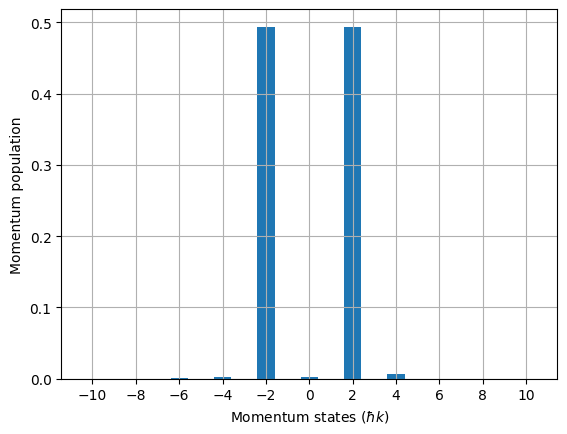

In [37]:
# Plot the final momentum state resulting from shaking with these optimised coefficients

# 1. Make the shaking function from the best coefficients from NM
controls_fn = make_controls_fn(N_basis, optimised_A, optimised_B, omegas, OLConstants().T, base_pulse)

# 2. Set up propagation
constants: OLConstants = OLConstants()
domain: QuantumHilbertSpace = QuantumHilbertSpace(
    num_dimensions=1,
    num_points=np.array([constants.num_pts]),
    position_bounds=np.array([[constants.lower_x_bound, constants.upper_x_bound]]),
    constants=constants,
    )
initial_state = GroundBlochState().generate_bloch_state()
state_initial: RVector = cast(
    RVector, domain.normalise_state(initial_state)
    )

hamiltonian: OpticalLatticeHamiltonian = OpticalLatticeHamiltonian(domain)

time_domain: TimeGrid = TimeGrid(time_min=0.0, time_max=constants.T, num_points=10001)

propagator = SplitOperator(hamiltonian, time_domain)

controls_fn = make_controls_fn(N_basis, optimised_A, optimised_B, omegas, constants.T, base_pulse)

# 3. Propagate the bloch state with the best shaking function
states: CTensors = propagator.propagate(
    state_initial, controls_fn, diagnostics=False
    )
final_state = states[-1]

# 4. Find the momentum state population of the final state

x_grid_spacing = GroundBlochState().x_grid[1] - GroundBlochState().x_grid[0]
mom_pop = momentum_space_population(final_state, x_grid_spacing)
momentum_idx = np.arange(-10, 12, 2)
# momentums = 2 * OLConstants().hbar * OLConstants().kl * momentum_idx

# 5. Plot final momentum state
plt.figure()
plt.bar(momentum_idx, mom_pop)
plt.xlabel('Momentum states ($\\hbar k$)')
plt.xticks(momentum_idx)
plt.ylabel('Momentum population')
plt.grid(True)

plt.show()

In [ ]:
# Save the simplex, omegas and base pulse from the final iteration
base_pulse = make_total_base_pulse(base_pulses)

optimised_err = get_error(optimised_A, optimised_B, omegas, N_basis, base_pulse)

folder = "crab_coefficients"
os.makedirs(folder, exist_ok=True)
error_str = f"{optimised_err:.6f}".replace(".", "p")
np.savetxt(
    f"{folder}/sorted_A_{error_str}.txt",
    sorted_a,
    fmt="%.16f"
)

np.savetxt(
    f"{folder}/sorted_B_{error_str}.txt",
    sorted_b,
    fmt="%.16f"
)
np.savetxt(
    f"{folder}/sorted_errs_{error_str}.txt",
    sorted_errs,
    fmt="%.16f"
)
np.savetxt(
    f"{folder}/omegas_{error_str}.txt",
    omegas,
    fmt="%.16f"
)
np.savetxt(
    f"{folder}/base_pulse_{error_str}.txt",
    base_pulse,
    fmt="%.16f"
)


ValueError: Expected 1D or 2D array, got 0D array instead